In [1]:
import pandas as pd
df = pd.read_csv("df_completo_e_imputado.csv", index_col=0, parse_dates=True)

In [2]:
df

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN,31
2025-09-01,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN,1
2025-09-02,5.683333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN,2
2025-09-03,5.700000,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3,5.70,3
2025-09-04,5.700000,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4,5.70,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-18,6.230000,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18,6.23,18
2026-04-19,6.230000,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19,6.23,19
2026-04-20,6.150000,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20,6.15,20


In [5]:
# fecha es de frecuencia diaria?
df.index.freq = pd.infer_freq(df.index)
df.index.freq

<Day>

In [6]:
df

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN,31
2025-09-01,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN,1
2025-09-02,5.683333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN,2
2025-09-03,5.700000,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3,5.70,3
2025-09-04,5.700000,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4,5.70,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-18,6.230000,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18,6.23,18
2026-04-19,6.230000,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19,6.23,19
2026-04-20,6.150000,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20,6.15,20


# Graficamos la serie

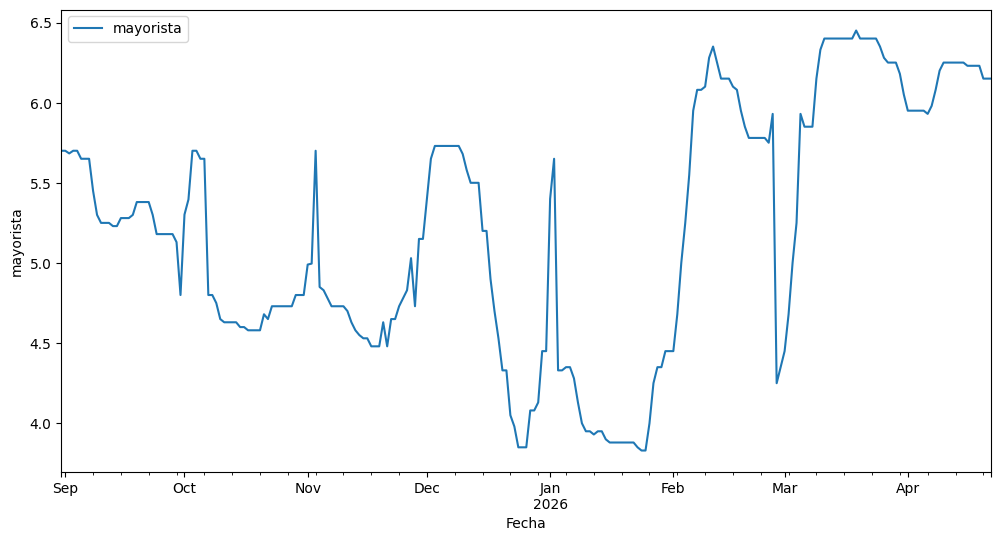

In [11]:
import matplotlib.pyplot as plt

df.plot(y="mayorista", figsize=(12, 6))
plt.xlabel("Fecha")
plt.ylabel("mayorista")
plt.show()

# Análisis

"A pesar de contar con 9 variables en el dataset, la descomposición de la serie temporal se aplicará exclusivamente a la variable 'mayorista', ya que es nuestra variable objetivo (endógena). Las restantes 8 variables (minorista, ofertas regionales, etc) serán tratadas como variables exógenas y se incorporarán en etapas posteriores del modelado. Se empleará un proceso de selección de características (feature selection) para identificar cuáles de estas variables exógenas aportan mayor poder predictivo al modelo final."

## Tendencia

In [14]:
df.index # el index es la fecha

DatetimeIndex(['2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03',
               '2025-09-04', '2025-09-05', '2025-09-06', '2025-09-07',
               '2025-09-08', '2025-09-09',
               ...
               '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16',
               '2026-04-17', '2026-04-18', '2026-04-19', '2026-04-20',
               '2026-04-21', '2026-04-22'],
              dtype='datetime64[ns]', name='fecha', length=235, freq='D')

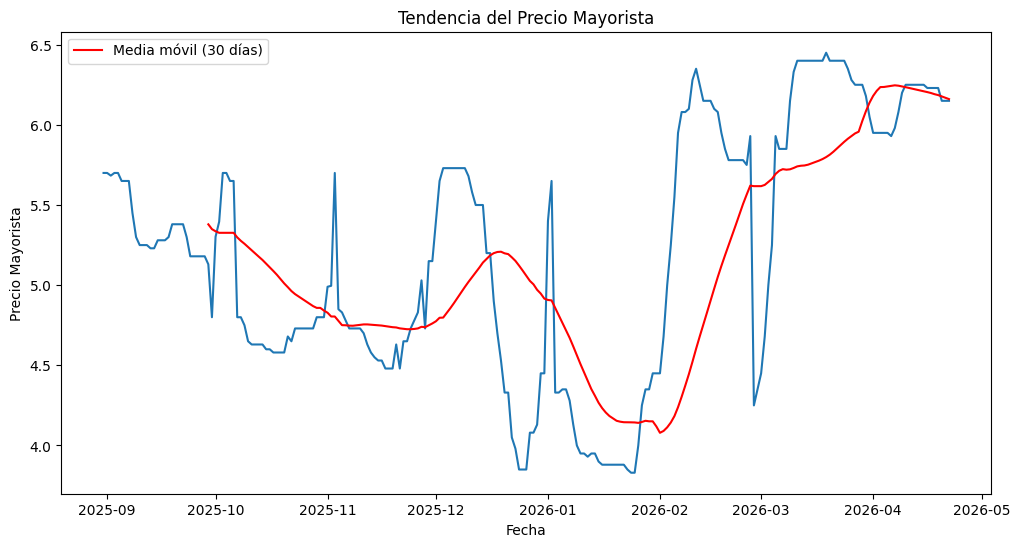

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['mayorista']) # (x,y)
# ahora hacemos MM de 30 días para ver tendencia y agregamos esa línea roja
plt.plot(df.index, df['mayorista'].rolling(window=30).mean(), # suavizamos para ver mejro la tendencia
         label='Media móvil (30 días)', color='red')
plt.xlabel('Fecha')

plt.ylabel('Precio Mayorista')
plt.legend()
plt.title('Tendencia del Precio Mayorista')
plt.show()

_Conclusión: No vemos una tendencia clara que crece o decrece, sería mejor analizarlo por tramos o hacer una descomposición (separar los componentes_

### Calculamos las desviaciones

In [38]:
df

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN,31
2025-09-01,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN,1
2025-09-02,5.683333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN,2
2025-09-03,5.700000,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3,5.70,3
2025-09-04,5.700000,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4,5.70,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-18,6.230000,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18,6.23,18
2026-04-19,6.230000,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19,6.23,19
2026-04-20,6.150000,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20,6.15,20


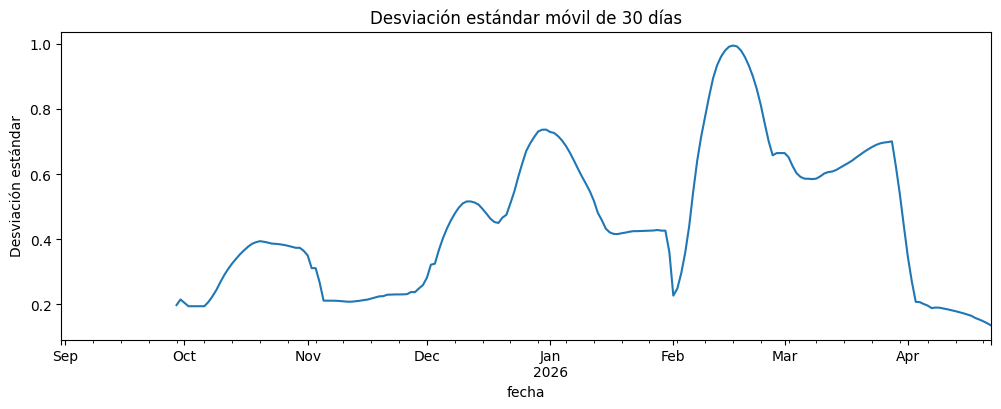

In [31]:
std_movil_30 = df["mayorista"].rolling(30).std()

std_movil_30.plot(figsize=(12,4))
plt.title("Desviación estándar móvil de 30 días")
plt.ylabel("Desviación estándar")
plt.show()

_La volatilidad no es constante (no homocedástica) comeinza baja y  sube gradualmente_

Cuando la varianza no es constante, el modelo puede confundirse porque asume que el “ruido” tiene una variabilidad relativamente estable. Si en algunos meses el precio se mueve poco y en otros se mueve muchísimo, el SARIMA puede ajustar mal y dar intervalos de predicción poco confiables.

In [32]:
# probamos con log pare recudir esa varianza ( al final debemos hacer exponencial para volver al precio original)
import numpy as np
serie_log = np.log(df["mayorista"])

In [35]:
serie_log

fecha
2025-08-31    1.740466
2025-09-01    1.740466
2025-09-02    1.737538
2025-09-03    1.740466
2025-09-04    1.740466
                ...   
2026-04-18    1.829376
2026-04-19    1.829376
2026-04-20    1.816452
2026-04-21    1.816452
2026-04-22    1.816452
Freq: D, Name: mayorista, Length: 235, dtype: float64

### revisamos la nueva desviación

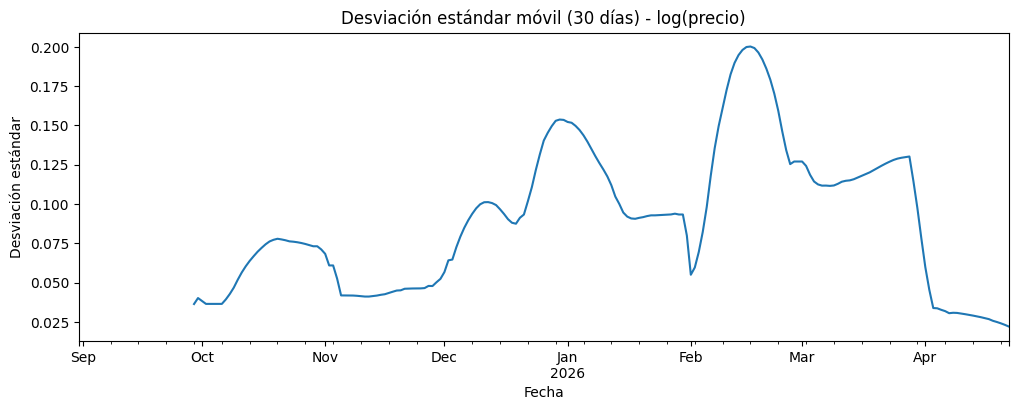

In [37]:
import matplotlib.pyplot as plt

# Desviación móvil
std_movil_log = serie_log.rolling(30).std()

# Gráfico
std_movil_log.plot(figsize=(12,4))
plt.title("Desviación estándar móvil (30 días) - log(precio)")
plt.ylabel("Desviación estándar")
plt.xlabel("Fecha")
plt.show()

Log no parece haber resuelto el problema, entonces La volatilidad no constante no parece deberse solo a que la variación crezca con el nivel del precio, sino a shocks o cambios de régimen en ciertos periodos. por lo que seguiremos con df

In [39]:
df

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN,31
2025-09-01,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN,1
2025-09-02,5.683333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN,2
2025-09-03,5.700000,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3,5.70,3
2025-09-04,5.700000,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4,5.70,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-18,6.230000,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18,6.23,18
2026-04-19,6.230000,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19,6.23,19
2026-04-20,6.150000,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20,6.15,20


La serie para implicar un modelo aditivo ya que  no crecen proporcionalmente cuando el precio sube. Es decir, cuando el precio está en 4 o en 6, las variaciones no parecen multiplicarse claramente por el nivel.

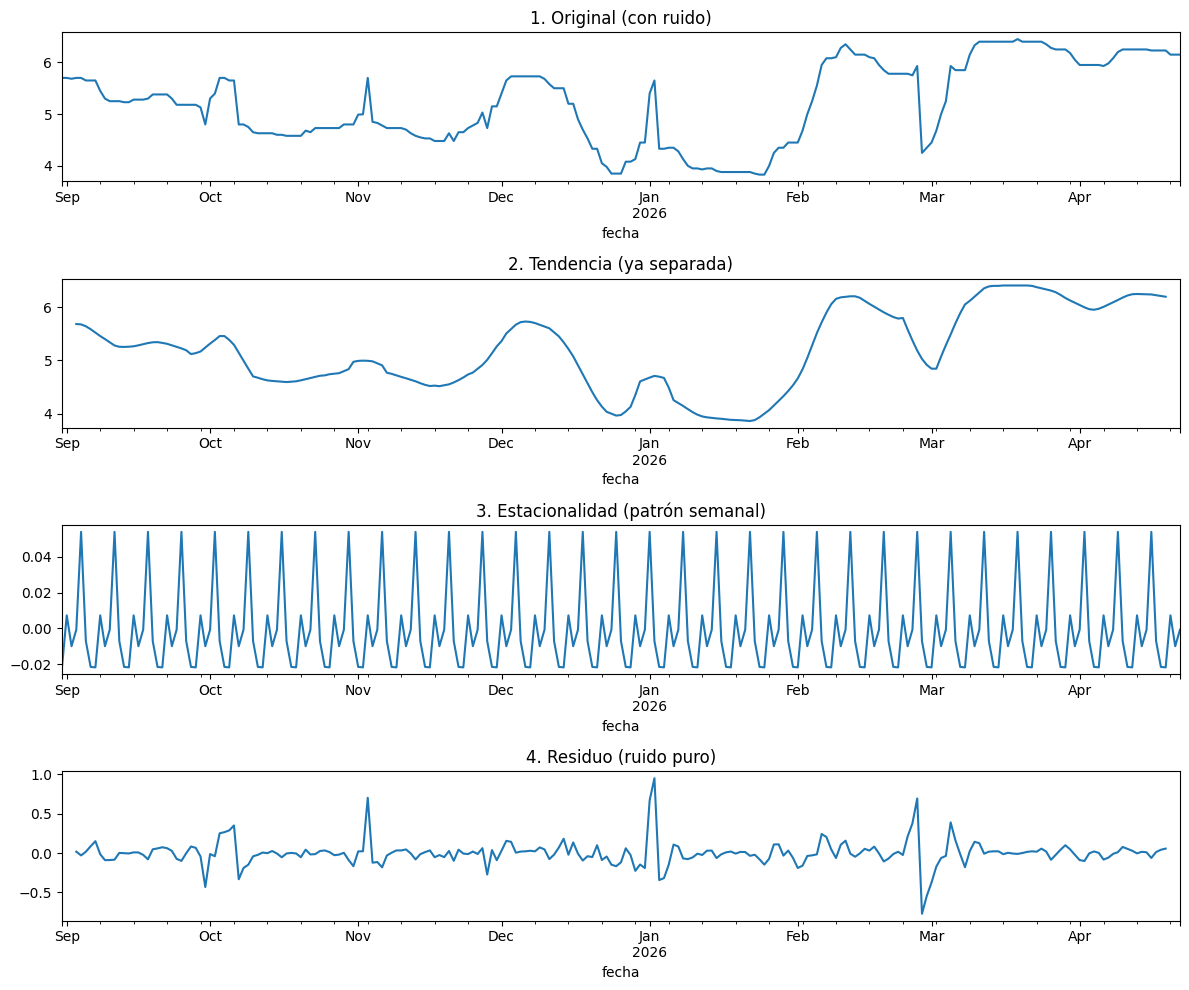

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Descomposición
resultado = seasonal_decompose(df['mayorista'], model='additive', period=7)

# Ver los 4 componentes
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
resultado.observed.plot(ax=axes[0], title='1. Original (con ruido)')
resultado.trend.plot(ax=axes[1], title='2. Tendencia (ya separada)')
resultado.seasonal.plot(ax=axes[2], title='3. Estacionalidad (patrón semanal)')
resultado.resid.plot(ax=axes[3], title='4. Residuo (ruido puro)')
plt.tight_layout()
plt.show()